## Basic ObsPy Example

This is a short example of a common ObsPy use case:
 * Download waveform data of an earthquake from a data center (via FDSN web service)
 * Download the corresponding station metadata including the frequency response (via FDSN web service)
 * Remove the instrument response from the waveform data to get physical units

For more detailed examples, check out e.g.:
 * [Seismo-Live](https://seismo-live.github.io/)
 * the [ObsPy Tutorial](https://docs.obspy.org/tutorial/index.html) pages

First, just some minimal setup for the plotting and adjustments currently needed for compatibility with web assembly

In [1]:
# this is required to monkey patch any urllib requests to use urllib3/requests.
# urllib is not WASM compatible. Emscripten tries to automatically reroute any of its download
# requests to a ws:// websocket which fails with a "Mixed content" error on an https:// deployment.

import pyodide_http
pyodide_http.patch_all()  # Patch all libraries

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 12, 8

In this example we download data from the Black Forest Observatory in Germany for the 2011 Tohoku earthquake

In [3]:
from obspy import UTCDateTime

network = "GR"
station = "BFO"
location = ""
channel = "LH*"
t = UTCDateTime("2011-03-11T05:46:23")  # Tohoku Earthquake
t1 = t + 10 * 60
t2 = t + 70 * 60

Now, download the waveform data from BGR server..

3 Trace(s) in Stream:
GR.BFO..LHE | 2011-03-11T05:56:23.296162Z - 2011-03-11T06:56:23.296162Z | 1.0 Hz, 3601 samples
GR.BFO..LHN | 2011-03-11T05:56:23.296161Z - 2011-03-11T06:56:23.296161Z | 1.0 Hz, 3601 samples
GR.BFO..LHZ | 2011-03-11T05:56:23.296160Z - 2011-03-11T06:56:23.296160Z | 1.0 Hz, 3601 samples


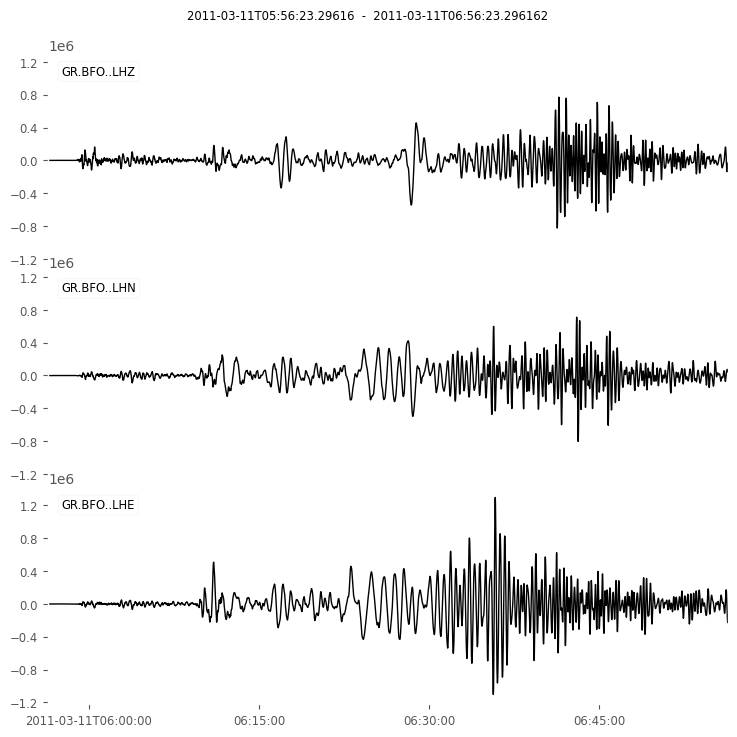

In [4]:
from obspy.clients.fdsn import Client

# service discovery uses multithreading which currently does not work here
# but it is not really needed here anyway, since it is mostly to discover
# custom query parameters the FDSN server might support in addition to
# the default query parameters
client = Client("BGR", _discover_services=False)

st = client.get_waveforms(network, station, location, channel, t1, t2)
print(st)
# semicolon to avoid jupyter showing the plot twice
st.plot();

These waveforms are still in arbitrary units (aka. "digital counts") and affected by the frequency response of the recording equipment. To make sense of the data in terms of actual amplitudes in physical units and also to see correct phase onset polarities (especially if close to the corner frequency), we download the corresponding station metadata including the instrument response.

Inventory created at 2026-05-26T12:51:14.395287Z
	Sending institution: SeisComP (BGR)
	Contains:
		Networks (1):
			GR
		Stations (1):
			GR.BFO (BGR Station GRSN Station Black Forest Observatory, Germany)
		Channels (3):
			GR.BFO..LHZ, GR.BFO..LHN, GR.BFO..LHE


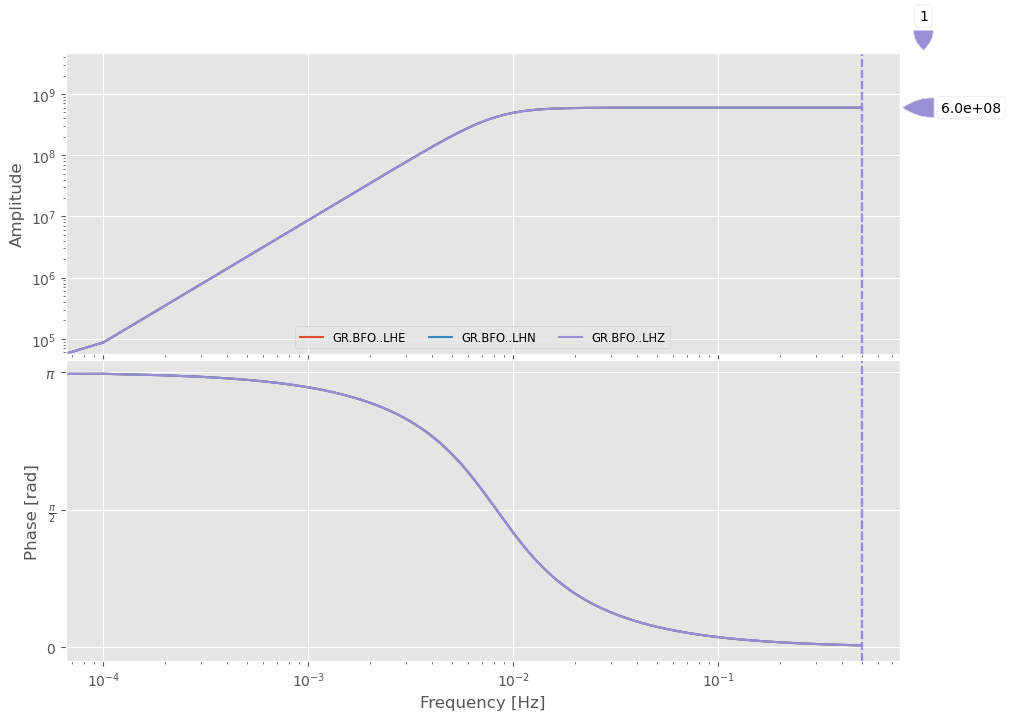

In [5]:
inventory = client.get_stations(
    network=network, station=station, location=location, channel=channel,
    starttime=t1, endtime=t2, level="response")
print(inventory)
# semicolon to avoid jupyter showing the plot twice
inventory.plot_response(min_freq=0.0001);

We can use the station metadata to correct for the instrument response and show the data in physical units, here as ground velocity in meter/second.

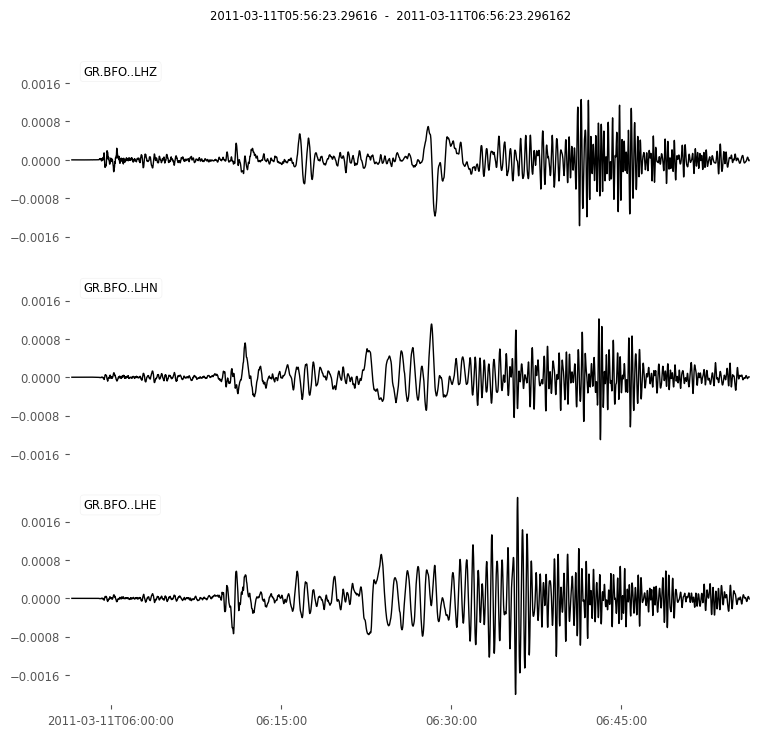

In [6]:
st.remove_response(inventory, water_level=10, output="VEL")
st.plot();